In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/README.DOC
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/TIMITDIC.TXT
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/TESTSET.DOC
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/train_data.csv
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/SPKRINFO.TXT
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/SPKRSENT.TXT
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/test_data.csv
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/TIMITDIC.DOC
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/PHONCODE.DOC
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/PROMPTS.TXT
/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data/TEST/DR4

In [5]:
import os

# Define the root path where Kaggle mounted the dataset
base_path = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data'

# List the main contents (usually containing 'TRAIN' and 'TEST' folders)
print(os.listdir(base_path))

['TEST', 'TRAIN']


In [7]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# 1. Define path to a specific speech sample
sample_file = os.path.join(base_path, 'TRAIN/DR1/FCJF0/SA1.WAV')

# 2. Load the audio signal (TIMIT native sampling rate is 16000 Hz)
# Setting sr=None keeps its native 16kHz rate instead of resampling to 22.05kHz
signal, sr = librosa.load(sample_file, sr=None)

print(f"Signal Shape: {signal.shape}")
print(f"Sampling Rate: {sr} Hz")
print(f"Duration: {len(signal)/sr:.2f} seconds")



Signal Shape: (46797,)
Sampling Rate: 16000 Hz
Duration: 2.92 seconds


In [8]:
import IPython.display as ipd

ipd.Audio(signal, rate=sr)

In [9]:
import os
import glob
import librosa
import numpy as np

# 1. Gather all WAV files in the training set
base_path = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data/TRAIN/**/*.WAV'
all_train_files = glob.glob(base_path, recursive=True)

# 2. Slice out a sufficient subset
subset_files = all_train_files[:150]
print(f"Total available files: {len(all_train_files)} | Using subset of: {len(subset_files)}")

# 3. Load and segment them into CS vectors
N = 512  # signal vector dimension (length of x)
training_segments = []

for file_path in subset_files:
    # Load native 16kHz
    signal, _ = librosa.load(file_path, sr=None)
    
    # Chop into non-overlapping or overlapping frames of size N
    # This prevents the autoencoder from dealing with variable lengths
    num_segments = len(signal) // N
    for i in range(num_segments):
        frame = signal[i*N : (i+1)*N]
        training_segments.append(frame)

# Convert to a solid NumPy array for your ML framework
X_train = np.array(training_segments)
print(f"Final Data Matrix Shape for Autoencoder: {X_train.shape}")
# Expected output shape: (Num_Segments, 512)

Total available files: 4620 | Using subset of: 150
Final Data Matrix Shape for Autoencoder: (14562, 512)


In [10]:
import glob
import librosa
import numpy as np

# 1. Gather all WAV files from the official TIMIT TEST directory
test_path_pattern = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data/TEST/**/*.WAV'
all_test_files = glob.glob(test_path_pattern, recursive=True)

# 2. Slice a small, manageable subset for testing (e.g., 30 sentences)
subset_test_files = all_test_files[:30]
print(f"Total test files available: {len(all_test_files)} | Evaluating on: {len(subset_test_files)}")

# 3. Use the exact same segment window size (N) as your training set
# N = 512 
test_segments = []

for file_path in subset_test_files:
    # Load native 16kHz audio
    signal, _ = librosa.load(file_path, sr=None)
    
    # Chop into non-overlapping frames of size N
    num_segments = len(signal) // N
    for i in range(num_segments):
        frame = signal[i*N : (i+1)*N]
        test_segments.append(frame)

# Convert to a NumPy array for inference
X_test = np.array(test_segments)

print("--- Data Generation Complete ---")
print(f"X_train shape: {X_train.shape}") # For context from previous step
print(f"X_test shape:  {X_test.shape}")

Total test files available: 1680 | Evaluating on: 30
--- Data Generation Complete ---
X_train shape: (14562, 512)
X_test shape:  (2723, 512)


In [11]:
import numpy as np

# Save to disk instantly in binary format
np.save('X_train_raw.npy', X_train)
np.save('X_test_raw.npy', X_test)
print("Saved as fast binary .npy files!")

# --- HOW TO LOAD THEM IN A FUTURE NOTEBOOK ---
# X_train = np.load('X_train.npy')
# X_test = np.load('X_test.npy')

Saved as fast binary .npy files!


# **Data Processing and Signal Denoising**

In [14]:
import torch
import scipy.signal as signal

In [15]:
train_path_pattern = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data/TRAIN/**/*.WAV'
all_train_files = glob.glob(train_path_pattern, recursive=True)

N = 512 

def spectral_subtraction(audio, fs=16000):
    """
    Performs STFT spectral subtraction denoising on continuous audio.
    """
    # Short-Time Fourier Transform (STFT)
    f, t_spec, Zxx = signal.stft(audio, fs=fs, nperseg=256, noverlap=128)
    
    # Estimate noise floor profile from initial silence window (approx. first 5 frames)
    noise_profile = np.mean(np.abs(Zxx[:, :5]), axis=1, keepdims=True)
    
    # Extract magnitude and phase
    magnitude = np.abs(Zxx)
    phase = np.angle(Zxx)
    
    # Subtract noise profile magnitude
    subtracted_magnitude = magnitude - noise_profile
    # Spectral floor to prevent negative value musical-noise artifacts
    subtracted_magnitude = np.maximum(subtracted_magnitude, 0.02 * magnitude) 
    
    # Reconstruct back to time domain
    Zxx_clean = subtracted_magnitude * np.exp(1j * phase)
    _, clean_audio = signal.istft(Zxx_clean, fs=fs, nperseg=256, noverlap=128)
    return clean_audio

print(f"Pipeline ready. Found {len(all_train_files)} training files.")

Pipeline ready. Found 4620 training files.


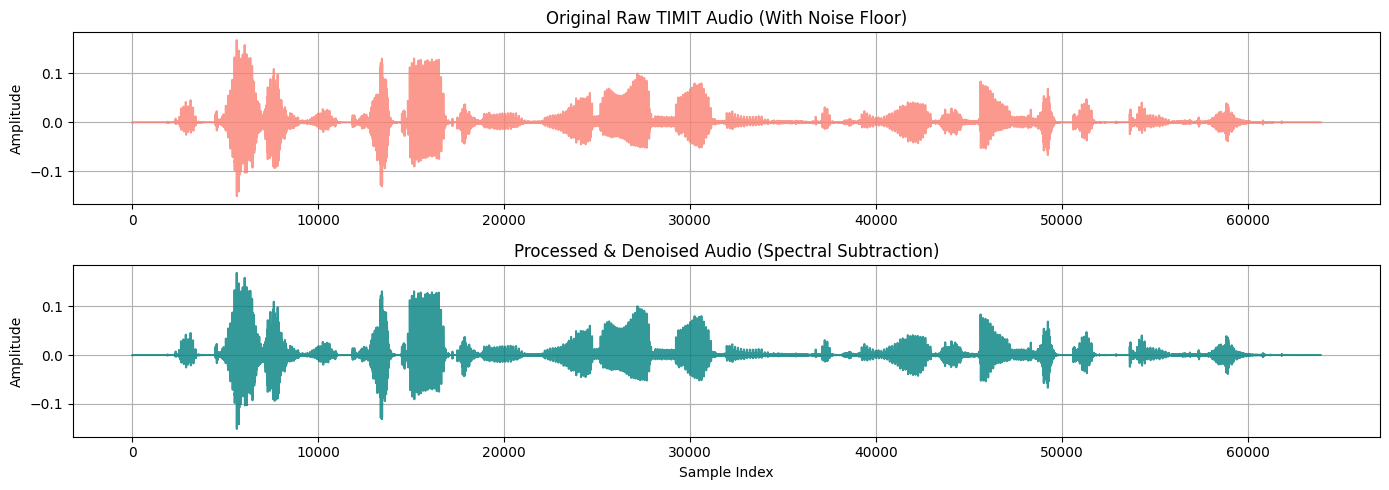

 LISTEN: Original Raw Audio:


 LISTEN: Processed & Denoised Audio:


In [16]:
sample_filepath = all_train_files[0]
raw_signal, sr = librosa.load(sample_filepath, sr=None) # Native 16kHz

# Apply denoising
clean_signal = spectral_subtraction(raw_signal, fs=sr)

# Ensure matching lengths for plotting
min_len = min(len(raw_signal), len(clean_signal))
raw_signal = raw_signal[:min_len]
clean_signal = clean_signal[:min_len]

# --- PLOTTING COMPARISON ---
plt.figure(figsize=(14, 5))

# Plot Raw Signal
plt.subplot(2, 1, 1)
plt.plot(raw_signal, color='salmon', alpha=0.8)
plt.title("Original Raw TIMIT Audio (With Noise Floor)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot Denoised Signal
plt.subplot(2, 1, 1) # Overlap or plot separate
plt.subplot(2, 1, 2)
plt.plot(clean_signal, color='teal', alpha=0.8)
plt.title("Processed & Denoised Audio (Spectral Subtraction)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- INTERACTIVE AUDIO PLAYERS ---
print(" LISTEN: Original Raw Audio:")
display(ipd.Audio(raw_signal, rate=sr))

print(" LISTEN: Processed & Denoised Audio:")
display(ipd.Audio(clean_signal, rate=sr))

**The dataset was already processed and samples were mostly noise-free**

In [17]:
# Define subset sizes
train_subset = all_train_files[:150]
test_path_pattern = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/data/TEST/**/*.WAV'
test_subset = glob.glob(test_path_pattern, recursive=True)[:30]

def process_and_frame_data(file_list, block_size=512):
    processed_frames = []
    
    for file_path in file_list:
        # 1. Load continuous audio
        sig, _ = librosa.load(file_path, sr=None)
        
        # 2. Denoise continuous audio
        sig_clean = spectral_subtraction(sig, fs=16000)
        
        # 3. Chop into blocks of N=512
        num_segments = len(sig_clean) // block_size
        for i in range(num_segments):
            frame = sig_clean[i*block_size : (i+1)*block_size]
            
            # Zero-mean normalization (remove DC offset)
            if np.max(np.abs(frame)) > 0:
                frame_normalized = frame - np.mean(frame)
                # Peak normalization
                frame_final = frame_normalized / np.max(np.abs(frame_normalized))
                processed_frames.append(frame_final)
                
    return np.array(processed_frames)

# Execute for both subsets
print("Processing and framing training set...")
X_train_processed = process_and_frame_data(train_subset, block_size=N)

print("Processing and framing test set...")
X_test_processed = process_and_frame_data(test_subset, block_size=N)

# Convert to PyTorch tensors as your code requested
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

print("\n--- Preprocessing Pipeline Complete ---")
print(f"Final PyTorch X_train Tensor Shape: {X_train_tensor.shape}")
print(f"Final PyTorch X_test Tensor Shape:  {X_test_tensor.shape}")

Processing and framing training set...
Processing and framing test set...

--- Preprocessing Pipeline Complete ---
Final PyTorch X_train Tensor Shape: torch.Size([14588, 512])
Final PyTorch X_test Tensor Shape:  torch.Size([2731, 512])


In [18]:
X_train_np = X_train_tensor.cpu().numpy()
X_test_np = X_test_tensor.cpu().numpy()

print("Saving processed arrays to disk...")

#  Save as native binary .npy files
np.save('X_train_processed.npy', X_train_np)
np.save('X_test_processed.npy', X_test_np)

print(" Done! Processed datasets saved successfully.")
print(f"Saved 'X_train_processed.npy' with shape: {X_train_np.shape}")
print(f"Saved 'X_test_processed.npy' with shape:  {X_test_np.shape}")

Saving processed arrays to disk...
✨ Done! Processed datasets saved successfully.
Saved 'X_train_processed.npy' with shape: (14588, 512)
Saved 'X_test_processed.npy' with shape:  (2731, 512)
